# K - Nearest Neighbours

## 1. Setup 

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from model_wrappers import ThresholdedClassifier, OutlierCapper
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

FINAL_K = 30  # number of features selected — matches the shared value used in Preprocess_expanded.ipynb

from sklearn.metrics import fbeta_score, make_scorer
# Candidate models are selected using F-beta (beta=2), not plain accuracy — this weights
# recall roughly twice as heavily as precision, which is more clinically defensible for a
# disease-screening tool: missing a real case (false negative) is worse than a false alarm.
# Plain recall alone isn't used, since a model that just predicts "disease" for everyone
# would trivially score perfect recall — F-beta still penalizes poor precision, just less
# heavily than F1 does.
CLINICAL_SCORER = make_scorer(fbeta_score, beta=2)

In [2]:
try:
    X_train_raw = joblib.load("X_train_raw.pkl")
    X_test_raw = joblib.load("X_test_raw.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train_raw:", X_train_raw.shape, "y_train:", y_train.shape)
    print("X_test_raw :", X_test_raw.shape, "y_test :", y_test.shape)

Loaded successfully
X_train_raw: (3996, 38) y_train: (3996,)
X_test_raw : (1000, 38) y_test : (1000,)


## 1.2 Results Log 
Tracks accuracy at every stage. **All exploratory/comparison entries use cross-validation on training data only** (`log_cv`) — the test set is not touched until the single \"Final Model Declaration\" section at the end (`log_test`), which is used exactly once. `candidate_models` keeps a reference to the actual fitted pipeline for each candidate, so the winning one can be retrieved and saved without having to re-decide anything by hand.\n\n**Note on the \"Accuracy\" column below:** during candidate *selection* (every entry logged via `log_cv`), the underlying scoring metric is actually **F-beta (beta=2)**, not plain accuracy — chosen to weight recall more heavily, since missing a real disease case is clinically worse than a false alarm. The column is still labeled \"Accuracy\" for consistency in this table, but a model's *true* accuracy, precision, recall, and F1 are only reported honestly once, in the Final Model Declaration section, from the untouched test set.

In [3]:
results_log = []
candidate_models = {}

def log_cv(name, acc, model=None):
    """Log a cross-validated (train-only) accuracy estimate."""
    try:
        acc = float(acc)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "CV (train only)"})
    if model is not None:
        candidate_models[name] = model
    print(f"[Logged - CV] {name}: {acc:.4f}")
    return acc

def log_test(name, y_true, y_pred):
    """Log a genuine held-out test accuracy. Reserved for the FINAL declared model only."""
    try:
        acc = accuracy_score(y_true, y_pred)
    except (ValueError, TypeError) as e:
        print(f"Could not log '{name}': {e}")
        return None
    results_log.append({"Stage": name, "Accuracy": acc, "Type": "TEST (final, touched once)"})
    print(f"[Logged - TEST] {name}: {acc:.4f}")
    return acc

## 2. Baseline Model 
Untuned KNN (`n_neighbors=15`, arbitrary), wrapped in a `Pipeline` with feature selection and scaling so it's evaluated the same leakage-free way as every other candidate below.

In [4]:
baseline_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=15, weights="uniform"))
])

try:
    cv_scores = cross_val_score(baseline_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during baseline cross-validation: {e}")
else:
    print("Baseline 10-fold CV Accuracy:", cv_scores.mean())
    log_cv("Baseline (n_neighbors=15)", cv_scores.mean(), model=baseline_pipeline)

Baseline 10-fold CV Accuracy: 0.8280981786711848
[Logged - CV] Baseline (n_neighbors=15): 0.8281


## 3. Hyperparameter Tuning 
Grid Search now tunes the full `Pipeline` (selector + scaler + classifier) together, so `SelectKBest` and `StandardScaler` are refit independently inside every one of the 10 folds — not fit once beforehand. `weights` is fixed to `'uniform'` throughout, avoiding the self-matching effect of `'distance'` weighting that inflated training accuracy earlier in this project.

In [5]:
pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])

param_grid = {
    "clf__n_neighbors": range(1, 61),
    "clf__weights": ["uniform"],
    "clf__metric": ["euclidean", "manhattan"]
}

try:
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=10,
        scoring=CLINICAL_SCORER,
        n_jobs=-1
    )
    grid_search.fit(X_train_raw, y_train)
except (ValueError, RuntimeError) as e:
    print(f"Error during Grid Search: {e}")
else:
    best_pipeline = grid_search.best_estimator_
    print("Best Hyperparameters:", grid_search.best_params_)
    print(f"Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")
    log_cv("Grid Search Tuned", grid_search.best_score_, model=best_pipeline)

Best Hyperparameters: {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'uniform'}
Best Cross-Validated Accuracy: 0.8363
[Logged - CV] Grid Search Tuned: 0.8363


## 4. Training-Set Sanity Check 
A quick check for gross overfitting using training data only — the real generalization gap is confirmed once, honestly, in the Final Model Declaration section using the untouched test set.

In [6]:
try:
    train_accuracy = best_pipeline.score(X_train_raw, y_train)
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error evaluating training accuracy: {e}")
else:
    print("Training Accuracy (best pipeline):", train_accuracy)
    print("(compare against the 10-fold CV accuracy above — a very large gap would flag overfitting)")

Training Accuracy (best pipeline): 0.8713713713713713
(compare against the 10-fold CV accuracy above — a very large gap would flag overfitting)


## 5. Model Stability — Cross-Validation & Accuracy vs. K 
Fold-by-fold view of the tuned pipeline's 10-fold CV accuracy, and an Accuracy vs. K sweep — each K value below is wrapped in its own fresh `Pipeline`, so selection/scaling are refit per fold for every K tested, not just for the final chosen one. \n\n**A note on \"loss curves\" for KNN:** unlike ANN, KNN has no training-time optimization loop — it's a *\"lazy learner\"* that just stores the data, so there's no loss to plot. The Accuracy vs. K plot below is the closest honest equivalent, playing the same diagnostic role.

Fold scores: [0.85322723 0.84145261 0.83406497 0.84738243 0.84594835 0.80053667
 0.82733813 0.84594835 0.84219858 0.82511211]
Average CV Accuracy: 0.8363209442537516


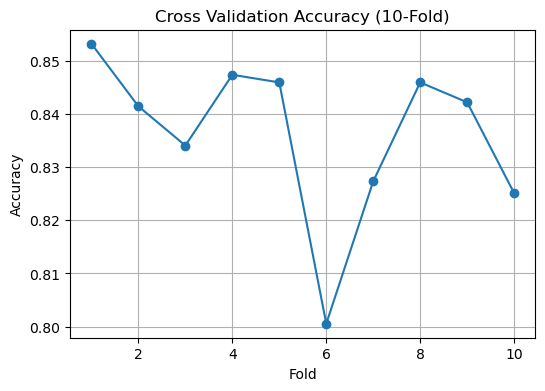

In [7]:
try:
    cv_scores = cross_val_score(best_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during cross-validation: {e}")
else:
    print("Fold scores:", cv_scores)
    print("Average CV Accuracy:", cv_scores.mean())

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), cv_scores, marker="o")
    plt.title("Cross Validation Accuracy (10-Fold)")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

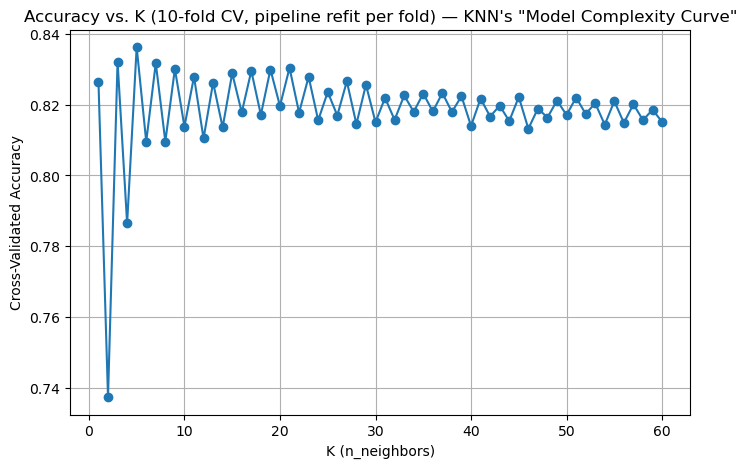

In [8]:
best_metric = grid_search.best_params_["clf__metric"]

k_range = range(1, 61)
k_scores = []

try:
    for k in k_range:
        temp_pipeline = Pipeline([
            ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
            ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=k, weights="uniform", metric=best_metric))
        ])
        scores = cross_val_score(temp_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
        k_scores.append(scores.mean())
except (ValueError, RuntimeError) as e:
    print(f"Error during K sweep: {e}")
else:
    plt.figure(figsize=(8, 5))
    plt.plot(k_range, k_scores, marker="o")
    plt.title("Accuracy vs. K (10-fold CV, pipeline refit per fold) — KNN's \"Model Complexity Curve\"")
    plt.xlabel("K (n_neighbors)")
    plt.ylabel("Cross-Validated Accuracy")
    plt.grid(True)
    plt.show()

## 6. Decision Threshold Optimization (Youden's J Statistic)
The optimal threshold is found using **out-of-fold predicted probabilities on the training set only** (`cross_val_predict`), so the test set plays no role in choosing it — the ROC curve and Youden's J (`Sensitivity + Specificity − 1`) are both computed against `y_train`, not `y_test`.

In [9]:
try:
    y_train_probs = cross_val_predict(best_pipeline, X_train_raw, y_train, cv=10, method="predict_proba")[:, 1]
    fpr, tpr, thresholds = roc_curve(y_train, y_train_probs)
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    y_train_pred_optimal = (y_train_probs >= best_threshold).astype(int)
except (ValueError, AttributeError, RuntimeError) as e:
    print(f"Error during threshold optimization: {e}")
else:
    print(f"Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): {best_threshold:.4f}")
    print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")
    cv_thresholded_acc = accuracy_score(y_train, y_train_pred_optimal)
    print("Out-of-fold accuracy at this threshold (train, CV-based):", cv_thresholded_acc)
    log_cv("Grid Search + Youden's J", cv_thresholded_acc, model=(best_pipeline, best_threshold))

Optimal threshold (found via 10-fold out-of-fold predictions on TRAINING data): 0.6000
Youden's J at this threshold: 0.6239
Out-of-fold accuracy at this threshold (train, CV-based): 0.815065065065065
[Logged - CV] Grid Search + Youden's J: 0.8151


## 6.2 Gaussian Weighted Voting 
KNN's model-specific \"extra formula\": instead of `uniform` (every neighbor votes equally) or `distance` (weight = 1/d, which can blow up sharply as d → 0), a **Gaussian kernel weight** gives closer neighbors a smoothly decaying influence: $$w_i = \\exp\\left(-\\frac{d_i^2}{2\\sigma^2}\\right)$$ This avoids the near-total self-voting blowup that caused the earlier 100% training-accuracy issue with `weights='distance'`, while still letting nearby points matter more than far ones. Evaluated via 10-fold CV on training data only, same as every other candidate.

In [10]:
def gaussian_weights(distances, sigma=1.0):
    return np.exp(-(distances**2) / (2 * sigma**2))

gaussian_pipeline = Pipeline([
    ("capper", OutlierCapper(columns=['trestbps', 'chol', 'thalch', 'oldpeak'])),
    ("selector", SelectKBest(score_func=f_classif, k=FINAL_K)),
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=15, weights=gaussian_weights))
])

try:
    gaussian_cv_scores = cross_val_score(gaussian_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during Gaussian-weighted KNN cross-validation: {e}")
else:
    print("Gaussian Weighting 10-fold CV Accuracy:", gaussian_cv_scores.mean())
    log_cv("Gaussian Weighted Voting", gaussian_cv_scores.mean(), model=gaussian_pipeline)

Gaussian Weighting 10-fold CV Accuracy: 0.8281584711907651
[Logged - CV] Gaussian Weighted Voting: 0.8282


## 6.3 Probability Calibration

KNN's `predict_proba()` output is just the raw vote fraction among the K neighbors (e.g. 9 out of 15 
neighbors say "disease" → 0.60) — this is a crude probability estimate, especially for small K, and 
isn't guaranteed to be well-calibrated. `CalibratedClassifierCV` learns a correction mapping from these 
raw vote fractions to better-calibrated probabilities, using an internal CV split so calibration isn't 
fit on the same data it's evaluated on. This matters directly here: Youden's J thresholding (Section 6) 
depends on `predict_proba()` being meaningful, not just correctly ranked.

In [11]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",  # good default for smaller datasets; try "isotonic" if you have a lot of data
    cv=5                # internal CV used to fit the calibration mapping itself
)

try:
    calibrated_cv_scores = cross_val_score(calibrated_pipeline, X_train_raw, y_train, cv=10, scoring=CLINICAL_SCORER)
except (ValueError, RuntimeError) as e:
    print(f"Error during calibration cross-validation: {e}")
else:
    print("Calibrated Model 10-fold CV Accuracy:", calibrated_cv_scores.mean())
    log_cv("Probability Calibration (sigmoid)", calibrated_cv_scores.mean(), model=calibrated_pipeline)

Calibrated Model 10-fold CV Accuracy: 0.8426449919369198
[Logged - CV] Probability Calibration (sigmoid): 0.8426


## 7. Final Model Declaration & Held-Out Test Evaluation 
Every candidate above was compared using cross-validation on training data only. This section picks the candidate with the **highest CV accuracy**, refits it (if needed) on the full training set, and evaluates it on `X_test_raw` / `y_test` — **the only place in this notebook the test set is used.** Whatever wins here is the exact object saved at the end, so the reported number and the deployed artifact are guaranteed to match.

In [12]:
cv_log = pd.DataFrame([r for r in results_log if r["Type"] == "CV (train only)"])
print(cv_log)

best_row = cv_log.loc[cv_log["Accuracy"].idxmax()]
best_stage_name = best_row["Stage"]
print(f"\n>>> Final chosen model: '{best_stage_name}' (CV accuracy = {best_row['Accuracy']:.4f})")

                               Stage  Accuracy             Type
0          Baseline (n_neighbors=15)  0.828098  CV (train only)
1                  Grid Search Tuned  0.836321  CV (train only)
2           Grid Search + Youden's J  0.815065  CV (train only)
3           Gaussian Weighted Voting  0.828158  CV (train only)
4  Probability Calibration (sigmoid)  0.842645  CV (train only)

>>> Final chosen model: 'Probability Calibration (sigmoid)' (CV accuracy = 0.8426)


[Logged - TEST] FINAL: Probability Calibration (sigmoid): 0.8110
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       438
           1       0.82      0.85      0.83       562

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



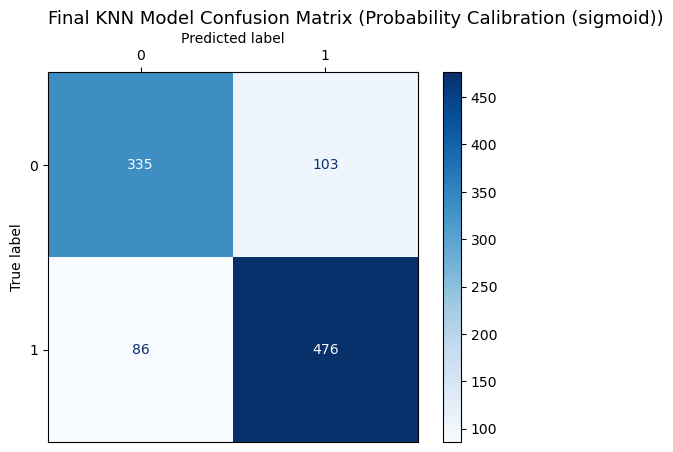

In [13]:
chosen = candidate_models[best_stage_name]

# the Youden's J candidate is stored as (pipeline, threshold) since it needs custom predict logic
if isinstance(chosen, tuple):
    inner_pipeline, final_threshold = chosen
    inner_pipeline.fit(X_train_raw, y_train)
    final_model_to_save = ThresholdedClassifier(inner_pipeline, threshold=final_threshold)
    final_model_to_save.classes_ = inner_pipeline.classes_
    final_pred = final_model_to_save.predict(X_test_raw)
    print(f"Final model is '{best_stage_name}' with a custom threshold of {final_threshold:.4f}")
else:
    final_pipeline = chosen
    final_pipeline.fit(X_train_raw, y_train)
    final_pred = final_pipeline.predict(X_test_raw)
    final_model_to_save = final_pipeline

test_accuracy = log_test(f"FINAL: {best_stage_name}", y_test, final_pred)
print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.title(f"Final KNN Model Confusion Matrix ({best_stage_name})", fontsize=13, loc='left')
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)
plt.show()

In [14]:
# ---------------------------------------------------------
# Save final results so app.py can display them AS-IS, without
# re-predicting on X_test_raw at deploy time
# ---------------------------------------------------------
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

try:
    y_proba_final = None
    if hasattr(final_model_to_save, "predict_proba"):
        y_proba_final = final_model_to_save.predict_proba(X_test_raw)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else float("nan")

    final_metrics = {
        "model_label": "KNN (K-Nearest Neighbors)",
        "best_stage_name": best_stage_name,
        "accuracy": test_accuracy,
        "precision_disease": precision_score(y_test, final_pred, pos_label=1, zero_division=0),
        "recall_disease": recall_score(y_test, final_pred, pos_label=1, zero_division=0),
        "specificity": specificity,
        "macro_f1": f1_score(y_test, final_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, final_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba_final) if y_proba_final is not None else float("nan"),
        "pr_auc": average_precision_score(y_test, y_proba_final) if y_proba_final is not None else float("nan"),
        "false_negatives": int(fn),
        "false_negative_rate": fn_rate,
        "n_test_samples": len(y_test),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }

    joblib.dump(final_metrics, "knn_metrics.pkl")
    print("Saved final metrics to knn_metrics.pkl:")
    for k, v in final_metrics.items():
        print(f"  {k}: {v}")
except (ValueError, RuntimeError, NameError) as e:
    print(f"Error saving final metrics: {e}")

Saved final metrics to knn_metrics.pkl:
  model_label: KNN (K-Nearest Neighbors)
  best_stage_name: Probability Calibration (sigmoid)
  accuracy: 0.811
  precision_disease: 0.8221070811744386
  recall_disease: 0.8469750889679716
  specificity: 0.7648401826484018
  macro_f1: 0.8071662726668904
  weighted_f1: 0.8105377775555825
  roc_auc: 0.8900392434066202
  pr_auc: 0.9041094222787835
  false_negatives: 86
  false_negative_rate: 0.15302491103202848
  n_test_samples: 1000
  confusion_matrix: {'tn': 335, 'fp': 103, 'fn': 86, 'tp': 476}


**Important note for `app.py`:** the saved model below is a full `Pipeline` (feature selection + scaling + classifier combined), not a bare classifier. If `app.py` currently applies its own manual scaling/feature-selection before calling `.predict()`, that logic should be **removed** — passing already-scaled/selected data into this pipeline would scale and select twice. `app.py` should instead pass the full raw feature row directly to `final_model.predict()`, and let the pipeline handle selection and scaling internally, exactly as it did during training.

## Permutation Importance

In [15]:
from sklearn.inspection import permutation_importance

# Run permutation importance on the test set using the fitted pipeline
pi_result = permutation_importance(
    final_model_to_save, 
    X_test_raw, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='accuracy'
)

# Sort and display feature importances
sorted_importances_idx = pi_result.importances_mean.argsort()[::-1]
for i in sorted_importances_idx:
    print(f"{X_test_raw.columns[i]:<30}: {pi_result.importances_mean[i]:.4f} +/- {pi_result.importances_std[i]:.4f}")

cp_atypical angina            : 0.0244 +/- 0.0064
cp_non-anginal                : 0.0136 +/- 0.0044
sex_Male                      : 0.0120 +/- 0.0064
oldpeak                       : 0.0107 +/- 0.0030
restecg_st-t abnormality      : 0.0106 +/- 0.0017
thalch                        : 0.0094 +/- 0.0047
restecg_normal                : 0.0091 +/- 0.0054
hr_reserve                    : 0.0091 +/- 0.0032
fbs_True                      : 0.0075 +/- 0.0025
cp_typical angina             : 0.0071 +/- 0.0024
trestbps                      : 0.0063 +/- 0.0046
fbs_missing                   : 0.0055 +/- 0.0028
chol_category_missing         : 0.0050 +/- 0.0027
chol                          : 0.0039 +/- 0.0022
predicted_max_hr              : 0.0038 +/- 0.0043
age                           : 0.0038 +/- 0.0043
bp_age_ratio                  : 0.0037 +/- 0.0046
thal_normal                   : 0.0029 +/- 0.0027
slope_upsloping               : 0.0025 +/- 0.0021
exang_True                    : 0.0024 +/- 0.0039


## 8. Full Accuracy Progression Log

In [16]:
log_df = pd.DataFrame(results_log)
log_df

,Stage,Accuracy,Type
0,Baseline (n_neighbors=15),0.828098,CV (train only)
1,Grid Search Tuned,0.836321,CV (train only)
2,Grid Search + Youden's J,0.815065,CV (train only)
3,Gaussian Weighted Voting,0.828158,CV (train only)
4,Probability Calibration (sigmoid),0.842645,CV (train only)
5,FINAL: Probability Calibration (sigmoid),0.811000,"TEST (final, touched once)"


In [17]:
# save the trained model
try:
    joblib.dump(final_model_to_save, 'knn_model.pkl')
except (OSError, PermissionError) as e:
    print(f"Error saving model: {e}")
else:
    print(f"Model saved successfully! ('{best_stage_name}', test accuracy = {test_accuracy:.4f})")

Model saved successfully! ('Probability Calibration (sigmoid)', test accuracy = 0.8110)
